In [1]:
print("Hello, ESOL!")

Hello, ESOL!


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print("数据行数和列数：", df.shape)
print("所有列名：", df.columns.tolist())
display(df.head())

数据行数和列数： (1128, 10)
所有列名： ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [3]:
print("每列缺失值：")
print(df.isna().sum())

print("完全相同的行数：", df.duplicated().sum())
print("重复的 SMILES 数：", df["smiles"].duplicated().sum())

target = "measured log solubility in mols per litre"
print("实测 logS 的统计：")
print(df[target].describe())

每列缺失值：
Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64
完全相同的行数： 0
重复的 SMILES 数： 0
实测 logS 的统计：
count    1128.000000
mean       -3.050102
std         2.096441
min       -11.600000
25%        -4.317500
50%        -2.860000
75%        -1.600000
max         1.580000
Name: measured log solubility in mols per litre, dtype: float64


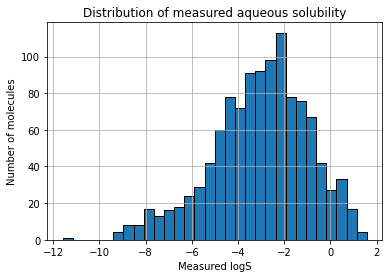

In [4]:
import matplotlib.pyplot as plt

df[target].hist(bins=30, edgecolor="black")
plt.xlabel("Measured logS")
plt.ylabel("Number of molecules")
plt.title("Distribution of measured aqueous solubility")
plt.show()

In [5]:
columns_to_show = ["Compound ID", "smiles", target, "Molecular Weight"]

print("水溶解度最低的5个：")
display(df.nsmallest(5, target)[columns_to_show])

print("水溶解度最高的5个：")
display(df.nlargest(5, target)[columns_to_show])

水溶解度最低的5个：


,Compound ID,smiles,measured log solubility in mols per litre,Molecular Weight
603,"2,2',3,3',4,4',5,5',6,6'-PCB",Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600,498.662
718,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,300.360
297,"2,2',3,3',4,4',5,5'-PCB",Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl,-9.160,429.772
60,"2,2',3,3',5,5',6,6'-PCB",Clc1cc(Cl)c(Cl)c(c1Cl)c2c(Cl)c(Cl)cc(Cl)c2Cl,-9.150,429.772
676,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,-9.018,276.338


水溶解度最高的5个：


,Compound ID,smiles,measured log solubility in mols per litre,Molecular Weight
605,Acetamide,CC(=O)N,1.580,59.068
146,Methanol,CO,1.570,32.042
201,Methyl hydrazine,CNN,1.340,46.073
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,287.343
679,Glycerol,OCC(O)CO,1.120,92.094


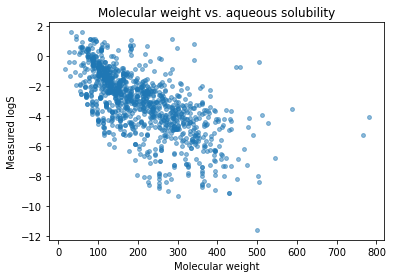

In [6]:
plt.scatter(df["Molecular Weight"], df[target], alpha=0.5, s=15)
plt.xlabel("Molecular weight")
plt.ylabel("Measured logS")
plt.title("Molecular weight vs. aqueous solubility")
plt.show()

In [7]:
correlation = df["Molecular Weight"].corr(df[target])
print("分子量与实测 logS 的相关系数：", round(correlation, 3))

分子量与实测 logS 的相关系数： -0.64


In [8]:
from pathlib import Path
print(Path.cwd())

/home/5cd30e40-6da9-4228-b571-9e35b407f004


In [9]:
from pathlib import Path
print(Path.cwd())

/home/5cd30e40-6da9-4228-b571-9e35b407f004


In [10]:
from rdkit import Chem
print(Chem.MolFromSmiles("CO") is not None)

True


In [11]:
%pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [12]:
from rdkit import Chem
print(Chem.MolFromSmiles("CO") is not None)

True


In [13]:
molecules = [Chem.MolFromSmiles(s) for s in df["smiles"]]

invalid_rows = [i for i, mol in enumerate(molecules) if mol is None]

print("分子总数：", len(molecules))
print("无法解析的分子数：", len(invalid_rows))
print("无法解析的行号：", invalid_rows[:10])

分子总数： 1128
无法解析的分子数： 0
无法解析的行号： []


In [14]:
canonical_smiles = [Chem.MolToSmiles(mol) for mol in molecules]

df["canonical_smiles"] = canonical_smiles

print("规范 SMILES 重复数：",
      df["canonical_smiles"].duplicated().sum())

规范 SMILES 重复数： 11


In [15]:
duplicate_mask = df["canonical_smiles"].duplicated(keep=False)

duplicate_records = df.loc[
    duplicate_mask,
    ["Compound ID", "smiles", "canonical_smiles", target]
].sort_values("canonical_smiles")

print("涉及重复的记录总数：", len(duplicate_records))
display(duplicate_records)

涉及重复的记录总数： 22


,Compound ID,smiles,canonical_smiles,measured log solubility in mols per litre
222,2-bromonaphthalene,c1c(Br)ccc2ccccc12,Brc1ccc2ccccc2c1,-4.400
554,2-Bromonapthalene,Brc1ccc2ccccc2c1,Brc1ccc2ccccc2c1,-4.400
213,eucalyptol,CC12CCC(CC1)C(C)(C)O2,CC12CCC(CC1)C(C)(C)O2,-1.640
976,"1,8-Cineole",CC12CCC(CC1)C(C)(C)O2,CC12CCC(CC1)C(C)(C)O2,-1.740
232,Epiandrosterone,CC34CCC1C(CCC2CC(O)CCC12C)C3CCC4=O,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,-4.160
655,Androsterone,CC12CCC(O)CC1CCC3C2CCC4(C)C3CCC4=O,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,-4.402
825,5-Ethyl-5-isopropylbarbituric acid,O=C1NC(=O)NC(=O)C1(CC)C(C)C,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.148
701,probarbital,CCC1(C(C)C)C(=O)NC(=O)NC1=O,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.210
147,Amobarbital,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.468
779,5-Ethyl-5-(3-methylbutyl)barbital,O=C1NC(=O)NC(=O)C1(CC)CCC(C)C,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.658


In [16]:
duplicate_summary = (
    duplicate_records
    .groupby("canonical_smiles")[target]
    .agg(["count", "min", "max"])
)

duplicate_summary["logS_difference"] = (
    duplicate_summary["max"] - duplicate_summary["min"]
)

display(
    duplicate_summary
    .sort_values("logS_difference", ascending=False)
)

,count,min,max,logS_difference
canonical_smiles,,,,
OCC(O)C(O)C(O)C(O)CO,2,0.060,1.090,1.030
CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,2,-4.402,-4.160,0.242
CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,2,-2.658,-2.468,0.190
CC12CCC(CC1)C(C)(C)O2,2,-1.740,-1.640,0.100
CCC1(C(C)C)C(=O)NC(=O)NC1=O,2,-2.210,-2.148,0.062
Cc1ncc([N+](=O)[O-])n1CCO,2,-1.260,-1.220,0.040
Brc1ccc2ccccc2c1,2,-4.400,-4.400,0.000
CCC1(c2ccccc2)C(=O)NC(=O)NC1=O,2,-2.322,-2.322,0.000
CCOP(=S)(OCC)SC(CCl)N1C(=O)c2ccccc2C1=O,2,-6.340,-6.340,0.000


In [17]:
df_clean = df.loc[~duplicate_mask].copy()

print("原始记录数：", len(df))
print("排除的记录数：", len(df) - len(df_clean))
print("第一版建模记录数：", len(df_clean))
print("剩余规范 SMILES 重复数：",
      df_clean["canonical_smiles"].duplicated().sum())

原始记录数： 1128
排除的记录数： 22
第一版建模记录数： 1106
剩余规范 SMILES 重复数： 0


In [18]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

clean_molecules = [
    Chem.MolFromSmiles(s) for s in df_clean["smiles"]
]

first_mol = clean_molecules[0]
print("分子量:", Descriptors.MolWt(first_mol))
print("脂水分配系数 LogP:", Crippen.MolLogP(first_mol))
print("拓扑极性表面积 TPSA:", rdMolDescriptors.CalcTPSA(first_mol))
print("分子数量:", len(clean_molecules))

分子量: 457.4320000000001
脂水分配系数 LogP: -3.1080199999999985
拓扑极性表面积 TPSA: 202.31999999999996
分子数量: 1106


In [19]:
df_clean["MolWt"] = [Descriptors.MolWt(mol) for mol in clean_molecules]
df_clean["LogP"] = [Crippen.MolLogP(mol) for mol in clean_molecules]
df_clean["TPSA"] = [rdMolDescriptors.CalcTPSA(mol) for mol in clean_molecules]

display(df_clean[["Compound ID", "MolWt", "LogP", "TPSA", target]].head())
print("描述符缺失值：")
print(df_clean[["MolWt", "LogP", "TPSA"]].isna().sum())

,Compound ID,MolWt,LogP,TPSA,measured log solubility in mols per litre
0,Amigdalin,457.432,-3.10802,202.32,-0.77
1,Fenfuram,201.225,2.84032,42.24,-3.30
2,citral,152.237,2.87800,17.07,-2.06
3,Picene,278.354,6.29940,0.00,-7.87
4,Thiophene,84.143,1.74810,0.00,-1.33


描述符缺失值：
MolWt    0
LogP     0
TPSA     0
dtype: int64


In [20]:
from rdkit.Chem import Lipinski

df_clean["HDonors"] = [
    Lipinski.NumHDonors(mol) for mol in clean_molecules
]
df_clean["HAcceptors"] = [
    Lipinski.NumHAcceptors(mol) for mol in clean_molecules
]
df_clean["RotatableBonds"] = [
    Lipinski.NumRotatableBonds(mol) for mol in clean_molecules
]
df_clean["RingCount"] = [
    Lipinski.RingCount(mol) for mol in clean_molecules
]

new_columns = ["HDonors", "HAcceptors", "RotatableBonds", "RingCount"]
display(df_clean[["Compound ID"] + new_columns].head())
print("缺失值：")
print(df_clean[new_columns].isna().sum())

,Compound ID,HDonors,HAcceptors,RotatableBonds,RingCount
0,Amigdalin,7,12,7,3
1,Fenfuram,1,2,2,2
2,citral,0,1,4,0
3,Picene,0,0,0,5
4,Thiophene,0,1,0,1


缺失值：
HDonors           0
HAcceptors        0
RotatableBonds    0
RingCount         0
dtype: int64


In [21]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.model_selection import train_test_split

feature_columns = [
    "MolWt", "LogP", "TPSA",
    "HDonors", "HAcceptors", "RotatableBonds", "RingCount"
]

X = df_clean[feature_columns].copy()
y = df_clean[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("输入表的形状：", X.shape)
print("训练集：", X_train.shape, y_train.shape)
print("测试集：", X_test.shape, y_test.shape)

输入表的形状： (1106, 7)
训练集： (884, 7) (884,)
测试集： (222, 7) (222,)


In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("基准预测值：", round(baseline_pred[0], 3))
print("MAE：", round(mean_absolute_error(y_test, baseline_pred), 3))
print("RMSE：", round(mean_squared_error(y_test, baseline_pred) ** 0.5, 3))
print("R²：", round(r2_score(y_test, baseline_pred), 3))

基准预测值： -3.056
MAE： 1.689
RMSE： 2.176
R²： -0.0


In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("岭回归 MAE：", round(mean_absolute_error(y_test, ridge_pred), 3))
print("岭回归 RMSE：", round(mean_squared_error(y_test, ridge_pred) ** 0.5, 3))
print("岭回归 R²：", round(r2_score(y_test, ridge_pred), 3))

岭回归 MAE： 0.771
岭回归 RMSE： 0.982
岭回归 R²： 0.796


In [25]:
error_table = df_clean.loc[
    X_test.index, ["Compound ID", target]
].copy()

error_table["predicted_logS"] = ridge_pred
error_table["absolute_error"] = (
    error_table[target] - error_table["predicted_logS"]
).abs()

display(
    error_table.sort_values("absolute_error", ascending=False).head(10)
)

,Compound ID,measured log solubility in mols per litre,predicted_logS,absolute_error
1064,vamidothion,1.144,-2.589623,3.733623
852,uric acid,-3.930,-0.381478,3.548522
938,isoguanine,-3.401,-0.960000,2.441000
640,Digitoxin,-5.293,-7.634734,2.341734
804,Azodrin,0.651,-1.673935,2.324935
141,"2,6-Dimethylpyridine",0.450,-1.817290,2.267290
249,"1,2-Benzenediol",0.620,-1.591090,2.211090
220,Perylene,-8.804,-6.720273,2.083727
128,Pyridine,0.760,-1.227857,1.987857
491,"2,2,4-Trimethylpentane",-4.740,-2.774201,1.965799


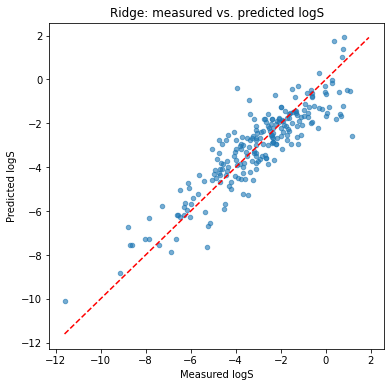

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ridge_pred, alpha=0.6, s=20)

lower = min(y_test.min(), ridge_pred.min())
upper = max(y_test.max(), ridge_pred.max())
plt.plot([lower, upper], [lower, upper], "r--")

plt.xlabel("Measured logS")
plt.ylabel("Predicted logS")
plt.title("Ridge: measured vs. predicted logS")
plt.show()

In [27]:
from rdkit.Chem.Scaffolds import MurckoScaffold

df_clean["scaffold"] = [
    MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    for mol in clean_molecules
]

print("不同骨架数：", df_clean["scaffold"].nunique())
print("空骨架记录数：", (df_clean["scaffold"] == "").sum())
print("记录最多的 10 种骨架：")
print(df_clean["scaffold"].value_counts().head(10))

不同骨架数： 266
空骨架记录数： 315
记录最多的 10 种骨架：
                                315
c1ccccc1                        252
c1ccc(-c2ccccc2)cc1              39
c1ccc2ccccc2c1                   20
O=C1CC(=O)NC(=O)N1               17
O=C1C=C2CCC3C4CCCC4CCC3C2CC1     17
c1ncncn1                         16
c1ccncc1                         14
c1ccc(Cc2ccccc2)cc1              10
C1CCCCC1                         10
Name: scaffold, dtype: int64


In [28]:
from sklearn.model_selection import GroupShuffleSplit

groups = df_clean["scaffold"].copy()
acyclic = groups == ""
groups.loc[acyclic] = (
    "acyclic:" + df_clean.loc[acyclic, "canonical_smiles"]
)

splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=42
)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train_scaf = X.iloc[train_idx]
X_test_scaf = X.iloc[test_idx]
y_train_scaf = y.iloc[train_idx]
y_test_scaf = y.iloc[test_idx]

train_scaffolds = set(df_clean.iloc[train_idx]["scaffold"]) - {""}
test_scaffolds = set(df_clean.iloc[test_idx]["scaffold"]) - {""}

print("训练记录数：", len(train_idx))
print("测试记录数：", len(test_idx))
print("两边共有的非空骨架数：",
      len(train_scaffolds & test_scaffolds))

训练记录数： 920
测试记录数： 186
两边共有的非空骨架数： 0


In [29]:
scaf_baseline = DummyRegressor(strategy="mean")
scaf_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

for name, model in [
    ("基准模型", scaf_baseline),
    ("岭回归", scaf_ridge)
]:
    model.fit(X_train_scaf, y_train_scaf)
    pred = model.predict(X_test_scaf)

    print(name)
    print("MAE:", round(mean_absolute_error(y_test_scaf, pred), 3))
    print("RMSE:", round(mean_squared_error(y_test_scaf, pred) ** 0.5, 3))
    print("R²:", round(r2_score(y_test_scaf, pred), 3))

基准模型
MAE: 1.711
RMSE: 2.16
R²: -0.006
岭回归
MAE: 0.856
RMSE: 1.059
R²: 0.758


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_scaf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_scaf.fit(X_train_scaf, y_train_scaf)
rf_scaf_pred = rf_scaf.predict(X_test_scaf)

print("训练集 MAE:",
      round(mean_absolute_error(
          y_train_scaf, rf_scaf.predict(X_train_scaf)
      ), 3))
print("测试集 MAE:",
      round(mean_absolute_error(y_test_scaf, rf_scaf_pred), 3))
print("测试集 RMSE:",
      round(mean_squared_error(y_test_scaf, rf_scaf_pred) ** 0.5, 3))
print("测试集 R²:",
      round(r2_score(y_test_scaf, rf_scaf_pred), 3))

训练集 MAE: 0.264
测试集 MAE: 0.597
测试集 RMSE: 0.806
测试集 R²: 0.86


In [31]:
rf_random = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
rf_random_pred = rf_random.predict(X_test)

print("随机划分测试集 MAE:",
      round(mean_absolute_error(y_test, rf_random_pred), 3))
print("随机划分测试集 RMSE:",
      round(mean_squared_error(y_test, rf_random_pred) ** 0.5, 3))
print("随机划分测试集 R²:",
      round(r2_score(y_test, rf_random_pred), 3))

随机划分测试集 MAE: 0.567
随机划分测试集 RMSE: 0.793
随机划分测试集 R²: 0.867


In [32]:
from sklearn.model_selection import GroupKFold, cross_val_score

cv = GroupKFold(n_splits=5)
train_groups = groups.iloc[train_idx]

for name, model in [
    ("岭回归", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("随机森林", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
]:
    fold_mae = -cross_val_score(
        model,
        X_train_scaf,
        y_train_scaf,
        groups=train_groups,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )
    print(name, "各折 MAE:", fold_mae.round(3))
    print("平均 MAE:", round(fold_mae.mean(), 3))

岭回归 各折 MAE: [0.668 0.778 0.837 0.776 0.872]
平均 MAE: 0.786
随机森林 各折 MAE: [0.641 0.552 0.515 0.582 0.664]
平均 MAE: 0.591


In [33]:
scaf_errors = df_clean.loc[
    X_test_scaf.index, ["Compound ID", "smiles", target]
].copy()

scaf_errors["predicted_logS"] = rf_scaf_pred
scaf_errors["absolute_error"] = (
    scaf_errors[target] - scaf_errors["predicted_logS"]
).abs()

display(scaf_errors.nlargest(10, "absolute_error"))

,Compound ID,smiles,measured log solubility in mols per litre,predicted_logS,absolute_error
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,-2.250618,3.394618
686,simazine,CCNc1nc(Cl)nc(NCC)n1,-4.550,-1.575071,2.974929
421,Chlorazine,CCN(CC)c1nc(Cl)nc(n1)N(CC)CC,-4.411,-1.975316,2.435684
894,Propazine,CC(C)Nc1nc(Cl)nc(NC(C)C)n1,-4.430,-2.218901,2.211099
872,Altretamine,CN(C)c1nc(nc(n1)N(C)C)N(C)C,-3.364,-1.244304,2.119696
66,Trietazine,CCNc1nc(Cl)nc(n1)N(CC)CC,-4.060,-2.052809,2.007191
819,Napthacene,c1ccc2cc3cc4ccccc4cc3cc2c1,-8.600,-6.732279,1.867721
174,cycloheximide,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2,-1.130,-2.936080,1.806080
245,Ipazine,CCN(CC)c1nc(Cl)nc(NC(C)C)n1,-3.785,-2.187395,1.597605
235,Atrazine,CCNc1nc(Cl)nc(NC(C)C)n1,-3.850,-2.261664,1.588336


In [34]:
scaf_errors["scaffold"] = df_clean.loc[scaf_errors.index, "scaffold"]

scaffold_errors = (
    scaf_errors[scaf_errors["scaffold"] != ""]
    .groupby("scaffold")
    .agg(
        molecule_count=("absolute_error", "size"),
        MAE=("absolute_error", "mean")
    )
)

display(
    scaffold_errors[scaffold_errors["molecule_count"] >= 3]
    .sort_values("MAE", ascending=False)
    .head(10)
)

,molecule_count,MAE
scaffold,,
c1ncncn1,16,1.417617
O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1,8,1.100040
c1ccc2c(c1)ccc1c3ccccc3ccc21,5,0.691351
O=C1CC(=O)N(c2ccccc2)N1c1ccccc1,3,0.610876
c1ccc(Cc2ccccc2)cc1,10,0.589234
O=c1cccnn1-c1ccccc1,3,0.586815
O=C1C=C2CCC3C4CCCC4CCC3C2CC1,17,0.489108
O=c1cc[nH]c(=O)[nH]1,7,0.413907
C1CCCCCCC1,3,0.343342


In [35]:
triazines = scaf_errors[
    scaf_errors["scaffold"] == "c1ncncn1"
].copy()

triazines["predicted_minus_measured"] = (
    triazines["predicted_logS"] - triazines[target]
)

print("分子数：", len(triazines))
print("平均预测偏差：", round(
    triazines["predicted_minus_measured"].mean(), 3
))

display(triazines[
    ["Compound ID", target, "predicted_logS", "predicted_minus_measured"]
])

分子数： 16
平均预测偏差： 1.418


,Compound ID,measured log solubility in mols per litre,predicted_logS,predicted_minus_measured
66,Trietazine,-4.060,-2.052809,2.007191
235,Atrazine,-3.850,-2.261664,1.588336
245,Ipazine,-3.785,-2.187395,1.597605
383,Prometon,-2.478,-1.885581,0.592419
421,Chlorazine,-4.411,-1.975316,2.435684
539,Ametryn,-3.040,-2.308692,0.731308
549,Terbutryn,-4.000,-2.667201,1.332799
636,Atratone,-2.084,-1.722725,0.361275
686,simazine,-4.550,-1.575071,2.974929
688,Simetryn,-2.676,-1.320907,1.355093


In [36]:
feature_importance = pd.Series(
    rf_scaf.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

display(feature_importance)

LogP              0.840837
MolWt             0.085312
TPSA              0.032472
RingCount         0.016107
HAcceptors        0.010625
RotatableBonds    0.009238
HDonors           0.005408
dtype: float64

In [37]:
X_train_no_logp = X_train_scaf.drop(columns="LogP")

rf_without_logp = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

mae_without_logp = -cross_val_score(
    rf_without_logp,
    X_train_no_logp,
    y_train_scaf,
    groups=train_groups,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("去掉 LogP 后，各折 MAE：", mae_without_logp.round(3))
print("平均 MAE：", round(mae_without_logp.mean(), 3))
print("原模型平均 MAE：0.594")

去掉 LogP 后，各折 MAE： [0.817 0.904 0.628 0.696 0.827]
平均 MAE： 0.775
原模型平均 MAE：0.594


In [38]:
import numpy as np
from rdkit.Chem import rdFingerprintGenerator

fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=512
)

fingerprints = np.array([
    fp_generator.GetFingerprintAsNumPy(mol)
    for mol in clean_molecules
])

X_fingerprint = pd.DataFrame(
    fingerprints,
    index=df_clean.index,
    columns=[f"FP_{i}" for i in range(512)]
)

print("指纹表形状：", X_fingerprint.shape)
print("第一个分子中值为 1 的位置数：", X_fingerprint.iloc[0].sum())

指纹表形状： (1106, 512)
第一个分子中值为 1 的位置数： 44


In [39]:
X_combined = pd.concat([X, X_fingerprint], axis=1)
X_combined_train = X_combined.iloc[train_idx]

print("合并后的训练集形状：", X_combined_train.shape)

rf_combined = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

combined_mae = -cross_val_score(
    rf_combined,
    X_combined_train,
    y_train_scaf,
    groups=train_groups,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("加入指纹后，各折 MAE：", combined_mae.round(3))
print("加入指纹后，平均 MAE：", round(combined_mae.mean(), 3))
print("原来 7 个描述符的平均 MAE：0.594")

合并后的训练集形状： (920, 519)
加入指纹后，各折 MAE： [0.645 0.547 0.529 0.576 0.668]
加入指纹后，平均 MAE： 0.593
原来 7 个描述符的平均 MAE：0.594


In [40]:
import joblib
from pathlib import Path

model_file = Path("esol_rf_7features.joblib")

joblib.dump(
    {
        "model": rf_scaf,
        "feature_columns": feature_columns
    },
    model_file
)

print("模型已保存到：", model_file.resolve())

模型已保存到： /home/5cd30e40-6da9-4228-b571-9e35b407f004/esol_rf_7features.joblib


In [41]:
import joblib
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Lipinski

saved = joblib.load("esol_rf_7features.joblib")

smiles = "COc1ccccc1O"  # 愈创木酚
mol = Chem.MolFromSmiles(smiles)

new_features = pd.DataFrame([{
    "MolWt": Descriptors.MolWt(mol),
    "LogP": Crippen.MolLogP(mol),
    "TPSA": rdMolDescriptors.CalcTPSA(mol),
    "HDonors": Lipinski.NumHDonors(mol),
    "HAcceptors": Lipinski.NumHAcceptors(mol),
    "RotatableBonds": Lipinski.NumRotatableBonds(mol),
    "RingCount": Lipinski.RingCount(mol)
}])[saved["feature_columns"]]

display(new_features)
print("预测 logS：", round(saved["model"].predict(new_features)[0], 3))

,MolWt,LogP,TPSA,HDonors,HAcceptors,RotatableBonds,RingCount
0,124.139,1.4008,29.46,1,2,1,1


预测 logS： -1.363


In [42]:
guaiacol_smiles = Chem.MolToSmiles(mol)
matches = df[df["canonical_smiles"] == guaiacol_smiles]

print("数据集中匹配的记录数：", len(matches))
display(matches[["Compound ID", target, "smiles"]])

for index in matches.index:
    if index in X_train_scaf.index:
        print("行", index, "位于训练集")
    elif index in X_test_scaf.index:
        print("行", index, "位于测试集")
    else:
        print("行", index, "未进入当前模型数据")

数据集中匹配的记录数： 2


,Compound ID,measured log solubility in mols per litre,smiles
680,Guaiacol,-1.96,COc1ccccc1O
1069,o-Methoxyphenol,-1.96,COc1ccccc1O


行 680 未进入当前模型数据
行 1069 未进入当前模型数据


In [43]:
for index, name in [
    (693, "苯甲醚"),
    (249, "邻苯二酚"),
    (680, "愈创木酚"),
    (1069, "o-Methoxyphenol")
]:
    if index in X_train_scaf.index:
        location = "训练集"
    elif index in X_test_scaf.index:
        location = "测试集"
    else:
        location = "已排除"

    print(name, index, location)

苯甲醚 693 训练集
邻苯二酚 249 训练集
愈创木酚 680 已排除
o-Methoxyphenol 1069 已排除


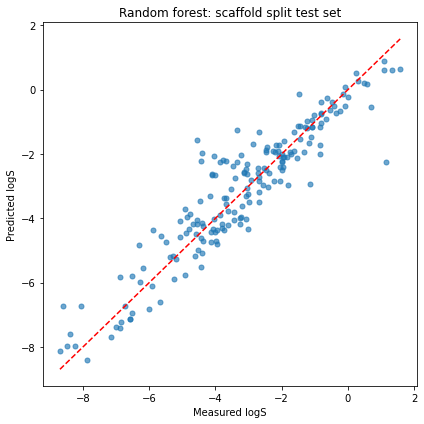

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_scaf, rf_scaf_pred, alpha=0.65, s=25)

lower = min(y_test_scaf.min(), rf_scaf_pred.min())
upper = max(y_test_scaf.max(), rf_scaf_pred.max())
plt.plot([lower, upper], [lower, upper], "r--")

plt.xlabel("Measured logS")
plt.ylabel("Predicted logS")
plt.title("Random forest: scaffold split test set")
plt.tight_layout()
plt.savefig("rf_scaffold_test.png", dpi=300)
plt.show()

## 第一版模型结论

本项目使用 ESOL 小分子水溶解度数据。原始数据有 1128 条记录；排除 22 条规范 SMILES 重复记录后，使用 1106 条记录建模。

模型输入为 7 个由分子结构计算的描述符。采用分子骨架分组划分训练集与测试集，使用随机森林预测 logS（水溶解度的对数值）。在 186 条留出测试记录上，MAE 为 0.596，RMSE 为 0.805，R² 为 0.860。

图中多数预测点接近代表“预测值等于实测值”的红色虚线，但部分分子误差较大，尤其是三嗪类分子。因此，模型可用于初步估计，具体分子的预测仍需结合实验数据判断。

In [45]:
print("MAE:", round(mean_absolute_error(y_test_scaf, rf_scaf_pred), 3))
print("RMSE:", round(mean_squared_error(y_test_scaf, rf_scaf_pred) ** 0.5, 3))
print("R²:", round(r2_score(y_test_scaf, rf_scaf_pred), 3))

MAE: 0.597
RMSE: 0.806
R²: 0.86


In [47]:
import pandas as pd
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

feature_sets = {
    "LogP only": ["LogP"],
    "LogP + MolWt": ["LogP", "MolWt"],
    "All 7 features": feature_columns
}

# 所有特征组合使用完全相同的5折分组划分
cv = GroupKFold(n_splits=5)
folds = list(cv.split(
    X_train_scaf,
    y_train_scaf,
    groups=train_groups
))

rows = []
subset_fold_mae = {}

for name, columns in feature_sets.items():
    model = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    fold_mae = -cross_val_score(
        model,
        X_train_scaf[columns],
        y_train_scaf,
        cv=folds,
        scoring="neg_mean_absolute_error"
    )

    subset_fold_mae[name] = fold_mae

    rows.append({
        "Feature set": name,
        "Feature count": len(columns),
        "Mean MAE": fold_mae.mean(),
        "Fold MAE std": fold_mae.std()
    })

comparison = pd.DataFrame(rows)
display(comparison.round(3))

,Feature set,Feature count,Mean MAE,Fold MAE std
0,LogP only,1,0.871,0.013
1,LogP + MolWt,2,0.659,0.043
2,All 7 features,7,0.591,0.055


In [48]:
fold_comparison = pd.DataFrame(
    subset_fold_mae,
    index=["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]
)
display(fold_comparison.round(3))

,LogP only,LogP + MolWt,All 7 features
Fold 1,0.854,0.704,0.641
Fold 2,0.863,0.664,0.552
Fold 3,0.863,0.599,0.515
Fold 4,0.882,0.620,0.582
Fold 5,0.890,0.706,0.664


### 特征组合比较

在相同的5折骨架分组交叉验证中，只使用 LogP、使用
LogP＋分子量、使用全部7个描述符的平均 MAE 分别为
0.871、0.659 和 0.591。

7个描述符在全部5折中均取得最低 MAE，说明在当前
数据和验证划分下，其他描述符提供了额外的预测信息。
因此保留7描述符模型。该结果不能证明每个描述符都
必不可少，也不能证明它们与溶解度存在因果关系。

In [50]:
leaf_rows = []
leaf_fold_mae = {}

for leaf_size in [1, 2, 4, 8]:
    model = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=leaf_size,
        random_state=42,
        n_jobs=-1
    )

    fold_mae = -cross_val_score(
        model,
        X_train_scaf[feature_columns],
        y_train_scaf,
        cv=folds,
        scoring="neg_mean_absolute_error"
    )

    leaf_fold_mae[leaf_size] = fold_mae

    leaf_rows.append({
        "min_samples_leaf": leaf_size,
        "Mean MAE": fold_mae.mean(),
        "Fold MAE std": fold_mae.std()
    })

leaf_comparison = pd.DataFrame(leaf_rows)
display(leaf_comparison.round(3))

,min_samples_leaf,Mean MAE,Fold MAE std
0,1,0.586,0.050
1,2,0.591,0.055
2,4,0.603,0.058
3,8,0.616,0.063


In [51]:
leaf_fold_table = pd.DataFrame(
    leaf_fold_mae,
    index=[f"Fold {i + 1}" for i in range(len(folds))]
)
leaf_fold_table.columns.name = "min_samples_leaf"

display(leaf_fold_table.round(3))

improvement = leaf_fold_table[2] - leaf_fold_table[1]

print("从 2 改为 1，各折 MAE 的降低量（正数表示改善）：")
print(improvement.round(3))
print("改善的折数：", int((improvement > 0).sum()), "/", len(folds))

min_samples_leaf,1,2,4,8
Fold 1,0.624,0.641,0.641,0.627
Fold 2,0.552,0.552,0.550,0.556
Fold 3,0.520,0.515,0.533,0.553
Fold 4,0.575,0.582,0.602,0.618
Fold 5,0.659,0.664,0.689,0.725


从 2 改为 1，各折 MAE 的降低量（正数表示改善）：
Fold 1    0.017
Fold 2   -0.000
Fold 3   -0.006
Fold 4    0.007
Fold 5    0.005
dtype: float64
改善的折数： 3 / 5


### 参数敏感性分析

固定七个分子描述符、200 棵树及相同的五折骨架分组，
比较叶节点最少样本数 min_samples_leaf 为 1、2、4、8 的表现。

对应的交叉验证平均 MAE 分别为 0.586、0.591、0.603、0.616。
从 2 调整为 1 后，五折中有三折改善，但平均 MAE 仅降低约 0.005，
说明本次验证中两者表现接近，尚不能确认参数 1 有稳定优势。

本项目保留原模型的 min_samples_leaf=2。
以上比较仅使用训练集内的交叉验证，未使用留出测试集选择参数。

In [52]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

stability_rows = []

for seed in [0, 1, 2, 3, 4]:
    stability_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=seed
    )

    fit_pos, val_pos = next(
        stability_splitter.split(
            X_train_scaf,
            y_train_scaf,
            groups=train_groups
        )
    )

    X_fit = X_train_scaf.iloc[fit_pos]
    X_val = X_train_scaf.iloc[val_pos]
    y_fit = y_train_scaf.iloc[fit_pos]
    y_val = y_train_scaf.iloc[val_pos]

    # 检查训练与验证之间是否有重复的分组
    fit_groups = set(train_groups.iloc[fit_pos])
    val_groups = set(train_groups.iloc[val_pos])
    assert len(fit_groups & val_groups) == 0

    models = {
        "Ridge": make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0)
        ),
        "Random forest": RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    }

    for name, model in models.items():
        model.fit(X_fit, y_fit)
        val_pred = model.predict(X_val)

        stability_rows.append({
            "Split seed": seed,
            "Model": name,
            "Train count": len(X_fit),
            "Validation count": len(X_val),
            "MAE": mean_absolute_error(y_val, val_pred)
        })

stability_results = pd.DataFrame(stability_rows)

display(stability_results.round(3))

stability_summary = (
    stability_results.groupby("Model")["MAE"]
    .agg(["mean", "std", "min", "max"])
)

display(stability_summary.round(3))

,Split seed,Model,Train count,Validation count,MAE
0,0,Ridge,789,131,0.797
1,0,Random forest,789,131,0.558
2,1,Ridge,804,116,0.703
3,1,Random forest,804,116,0.613
4,2,Ridge,801,119,0.878
5,2,Random forest,801,119,0.579
6,3,Ridge,804,116,0.805
7,3,Random forest,804,116,0.555
8,4,Ridge,771,149,0.741
9,4,Random forest,771,149,0.601


,mean,std,min,max
Model,,,,
Random forest,0.581,0.026,0.555,0.613
Ridge,0.785,0.067,0.703,0.878


### 分组划分稳定性检查

在原有的 920 条训练记录内部，使用五个随机种子重新进行
分组训练／验证划分，每次确保训练与验证之间没有分组重叠。

随机森林在五次划分中均优于岭回归：
随机森林平均 MAE 为 0.581，划分间标准差为 0.026；
岭回归平均 MAE 为 0.785，划分间标准差为 0.067。

结果支持随机森林在本次检查中具有较一致的性能优势。
不同划分的验证记录可能重叠，因此这些结果属于内部稳定性分析，
不代表独立外部验证。原有 186 条留出测试记录未参与本次比较。

,mean_train_count,mean_train_MAE,mean_validation_MAE
Group fraction,,,
0.2,175.8,0.319,0.731
0.4,324.2,0.298,0.659
0.6,525.0,0.270,0.609
0.8,628.6,0.268,0.605
1.0,736.0,0.265,0.591


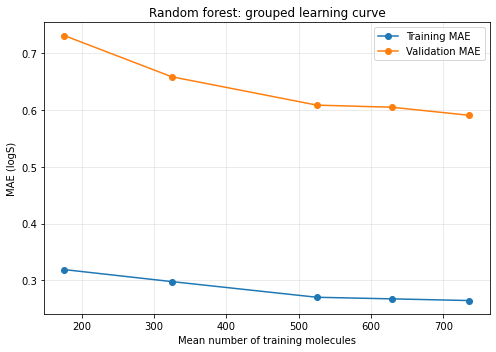

In [53]:
import numpy as np
import matplotlib.pyplot as plt

learning_rows = []
group_array = train_groups.to_numpy()

for fold_number, (fit_pos, val_pos) in enumerate(folds, start=1):
    # 每折内部，把训练分组随机排序
    available_groups = pd.unique(group_array[fit_pos])
    rng = np.random.default_rng(100 + fold_number)
    ordered_groups = rng.permutation(available_groups)

    for fraction in [0.2, 0.4, 0.6, 0.8, 1.0]:
        # 按完整分组取样，较大的子集包含较小的子集
        group_count = max(
            1,
            int(np.ceil(len(ordered_groups) * fraction))
        )
        chosen_groups = ordered_groups[:group_count]

        selected_pos = fit_pos[
            np.isin(group_array[fit_pos], chosen_groups)
        ]

        X_small = X_train_scaf.iloc[selected_pos]
        y_small = y_train_scaf.iloc[selected_pos]
        X_validation = X_train_scaf.iloc[val_pos]
        y_validation = y_train_scaf.iloc[val_pos]

        curve_model = RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        curve_model.fit(X_small, y_small)

        learning_rows.append({
            "Fold": fold_number,
            "Group fraction": fraction,
            "Train count": len(X_small),
            "Train MAE": mean_absolute_error(
                y_small, curve_model.predict(X_small)
            ),
            "Validation MAE": mean_absolute_error(
                y_validation,
                curve_model.predict(X_validation)
            )
        })

learning_results = pd.DataFrame(learning_rows)

learning_summary = (
    learning_results.groupby("Group fraction")
    .agg(
        mean_train_count=("Train count", "mean"),
        mean_train_MAE=("Train MAE", "mean"),
        mean_validation_MAE=("Validation MAE", "mean")
    )
)

display(learning_summary.round(3))

plt.figure(figsize=(7, 5))
plt.plot(
    learning_summary["mean_train_count"],
    learning_summary["mean_train_MAE"],
    "o-", label="Training MAE"
)
plt.plot(
    learning_summary["mean_train_count"],
    learning_summary["mean_validation_MAE"],
    "o-", label="Validation MAE"
)
plt.xlabel("Mean number of training molecules")
plt.ylabel("MAE (logS)")
plt.title("Random forest: grouped learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
import sys
import platform
from importlib.metadata import version

print("Python:", sys.version.split()[0])
print("System:", platform.platform())

for package in [
    "numpy", "pandas", "scikit-learn",
    "rdkit", "matplotlib", "joblib"
]:
    print(f"{package}: {version(package)}")

Python: 3.9.12
System: Linux-6.8.0-1044-aws-x86_64-with-glibc2.31
numpy: 1.21.5
pandas: 1.4.2
scikit-learn: 1.0.2
rdkit: 2025.9.2
matplotlib: 3.5.1
joblib: 1.1.0


### 拓展实验汇总

MAE（Mean Absolute Error，平均绝对误差）越低越好。

| 实验 | 当前环境下的结果 | 结论 |
|---|---|---|
| 特征比较 | 仅 LogP：0.871；LogP + MolWt：0.659；七个描述符：0.591 | 七个描述符在五折中均优于两个较小的特征集合 |
| 参数敏感性 | min_samples_leaf 为 1、2、4、8 时，平均 MAE 分别为 0.586、0.591、0.603、0.616 | 1 与 2 表现接近，保留原参数 2 |
| 划分稳定性 | 五次分组划分：随机森林平均 MAE 0.581，岭回归 0.785 | 随机森林五次均优于岭回归 |
| 学习曲线 | 平均训练分子数从约 176 增至 736，验证 MAE 从 0.731 降至 0.591 | 增加数据有改善迹象，但后期改善趋缓 |

上述实验均在原有 920 条训练记录内部进行。
五折验证和重复分组划分属于不同验证方案，其均值应分别报告。
这些结果属于内部验证，不代表独立外部验证。

学习曲线仍存在训练与验证误差差距，后续需要研究模型对不同
化学结构的适用范围，并使用经过来源和重复检查的新数据验证。

In [55]:
from sklearn.model_selection import cross_val_predict

analysis_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# 使用之前固定的五折分组划分
oof_pred = cross_val_predict(
    analysis_model,
    X_train_scaf[feature_columns],
    y_train_scaf,
    cv=folds
)

oof_errors = df_clean.loc[
    X_train_scaf.index,
    ["Compound ID", "canonical_smiles", "scaffold"]
].copy()

oof_errors["measured_logS"] = y_train_scaf
oof_errors["predicted_logS"] = oof_pred

# 正数：预测溶解度偏高；负数：预测偏低
oof_errors["signed_error"] = (
    oof_errors["predicted_logS"]
    - oof_errors["measured_logS"]
)
oof_errors["absolute_error"] = (
    oof_errors["signed_error"].abs()
)

# 空骨架分子结构差异较大，本表先分析非空骨架
oof_scaffold_summary = (
    oof_errors.loc[oof_errors["scaffold"] != ""]
    .groupby("scaffold")
    .agg(
        molecule_count=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        mean_bias=("signed_error", "mean"),
        overprediction_fraction=(
            "signed_error",
            lambda values: (values > 0).mean()
        )
    )
)

display(
    oof_scaffold_summary
    .loc[lambda table: table["molecule_count"] >= 5]
    .sort_values("MAE", ascending=False)
    .head(10)
    .round(3)
)

,molecule_count,MAE,mean_bias,overprediction_fraction
scaffold,,,,
c1ccncc1,14,1.208,-1.145,0.071
c1cnc2ncncc2n1,9,1.138,-1.138,0.000
O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1,7,1.122,0.474,0.714
c1ccc2cc3ccccc3cc2c1,6,1.017,1.017,1.000
c1ccccc1,252,0.641,0.033,0.575
O=C1CN=C(c2ccccc2)c2ccccc2N1,6,0.635,-0.061,0.500
c1ccc(-c2ccccc2)cc1,39,0.623,0.259,0.590
O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,9,0.595,0.576,0.889
c1cncnc1,5,0.584,-0.091,0.600


In [56]:
focus_scaffold = "c1ccncc1"

focus_errors = (
    oof_errors.loc[
        oof_errors["scaffold"] == focus_scaffold
    ]
    .sort_values("signed_error")
    .copy()
)

# 加入模型使用的七个描述符，方便检查结构与误差
focus_errors = focus_errors.join(
    X_train_scaf[feature_columns]
)

display(
    focus_errors[
        [
            "Compound ID",
            "canonical_smiles",
            "measured_logS",
            "predicted_logS",
            "signed_error",
            "absolute_error"
        ] + feature_columns
    ].round(3)
)

print("分子数：", len(focus_errors))
print(
    "预测偏低的分子数：",
    int((focus_errors["signed_error"] < 0).sum())
)
print(
    "绝对误差中位数：",
    round(focus_errors["absolute_error"].median(), 3)
)

,Compound ID,canonical_smiles,measured_logS,predicted_logS,signed_error,absolute_error,MolWt,LogP,TPSA,HDonors,HAcceptors,RotatableBonds,RingCount
868,2-Ethyl pyridine,CCc1ccccn1,0.510,-1.259,-1.769,1.769,107.156,1.644,12.89,0,1,1,1
141,"2,6-Dimethylpyridine",Cc1cccc(C)n1,0.450,-1.141,-1.591,1.591,107.156,1.698,12.89,0,1,0,1
791,Isonazid,NNC(=O)c1ccncc1,0.009,-1.555,-1.564,1.564,137.142,-0.315,68.01,2,3,1,1
216,"2,3-Dimethylpyridine",Cc1cccnc1C,0.380,-1.141,-1.521,1.521,107.156,1.698,12.89,0,1,0,1
612,"2,4-Dimethylpyridine",Cc1ccnc(C)c1,0.380,-1.141,-1.521,1.521,107.156,1.698,12.89,0,1,0,1
954,"3,5-Dimethylpyridine",Cc1cncc(C)c1,0.380,-1.141,-1.521,1.521,107.156,1.698,12.89,0,1,0,1
130,"3,4-Dimethylpyridine",Cc1ccncc1C,0.360,-1.141,-1.501,1.501,107.156,1.698,12.89,0,1,0,1
599,2-Hydroxypyridine,Oc1ccccn1,1.020,-0.247,-1.267,1.267,95.101,0.787,33.12,1,2,0,1
1100,4-hydroxypyridine,Oc1ccncc1,1.020,-0.247,-1.267,1.267,95.101,0.787,33.12,1,2,0,1
1043,nicotinamide,NC(=O)c1cccnc1,0.610,-0.603,-1.213,1.213,122.127,0.181,55.98,1,2,1,1


分子数： 14
预测偏低的分子数： 13
绝对误差中位数： 1.384


In [57]:
focus_mask = (
    df_clean.loc[X_train_scaf.index, "scaffold"]
    == focus_scaffold
).to_numpy()

focus_pos = np.flatnonzero(focus_mask)
background_pos = np.flatnonzero(~focus_mask)

X_focus = X_train_scaf.iloc[focus_pos]
y_focus = y_train_scaf.iloc[focus_pos]

X_background = X_train_scaf.iloc[background_pos]
y_background = y_train_scaf.iloc[background_pos]
background_groups = train_groups.iloc[background_pos]

focus_robustness_rows = []

for seed in [0, 1, 2, 3, 4]:
    background_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=seed
    )

    selected_pos, _ = next(
        background_splitter.split(
            X_background,
            y_background,
            groups=background_groups
        )
    )

    focus_model = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    focus_model.fit(
        X_background.iloc[selected_pos],
        y_background.iloc[selected_pos]
    )

    focus_pred = focus_model.predict(X_focus)
    signed_errors = focus_pred - y_focus.to_numpy()

    focus_robustness_rows.append({
        "Seed": seed,
        "Train count": len(selected_pos),
        "Focus MAE": np.abs(signed_errors).mean(),
        "Mean bias": signed_errors.mean(),
        "Underpredicted count": int((signed_errors < 0).sum())
    })

focus_robustness = pd.DataFrame(focus_robustness_rows)
display(focus_robustness.round(3))

,Seed,Train count,Focus MAE,Mean bias,Underpredicted count
0,0,778,1.280,-1.206,12
1,1,788,1.198,-1.119,12
2,2,792,1.261,-1.210,13
3,3,793,1.220,-1.148,13
4,4,757,1.298,-1.240,13


In [58]:
print("原训练集记录数：", len(X_train_scaf))
print("目标骨架记录数：", len(X_focus))
print("背景记录数：", len(X_background))
print("两者合计：", len(X_focus) + len(X_background))

print(
    "背景与目标分子索引重叠数：",
    len(set(X_background.index) & set(X_focus.index))
)

print(
    "背景与原留出测试集索引重叠数：",
    len(set(X_background.index) & set(X_test_scaf.index))
)

assert len(X_train_scaf) == 920
assert len(X_focus) == 14
assert len(X_background) == 906
assert len(set(X_background.index) & set(X_focus.index)) == 0
assert len(set(X_background.index) & set(X_test_scaf.index)) == 0

print("数据范围检查通过")

原训练集记录数： 920
目标骨架记录数： 14
背景记录数： 906
两者合计： 920
背景与目标分子索引重叠数： 0
背景与原留出测试集索引重叠数： 0
数据范围检查通过


In [59]:
# 原数据中的两条记录
pair_indices = [599, 1100]

display(
    focus_errors.loc[
        pair_indices,
        ["Compound ID", "canonical_smiles"] + feature_columns
    ].round(6)
)

feature_difference = (
    X_train_scaf.loc[599, feature_columns]
    - X_train_scaf.loc[1100, feature_columns]
)

print("七个描述符的差值：")
display(feature_difference)

print(
    "七个描述符是否近似相同：",
    np.allclose(
        X_train_scaf.loc[599, feature_columns].to_numpy(dtype=float),
        X_train_scaf.loc[1100, feature_columns].to_numpy(dtype=float),
        rtol=0,
        atol=1e-10
    )
)

,Compound ID,canonical_smiles,MolWt,LogP,TPSA,HDonors,HAcceptors,RotatableBonds,RingCount
599,2-Hydroxypyridine,Oc1ccccn1,95.101,0.7872,33.12,1,2,0,1
1100,4-hydroxypyridine,Oc1ccncc1,95.101,0.7872,33.12,1,2,0,1


七个描述符的差值：


MolWt             1.421085e-14
LogP              0.000000e+00
TPSA              0.000000e+00
HDonors           0.000000e+00
HAcceptors        0.000000e+00
RotatableBonds    0.000000e+00
RingCount         0.000000e+00
dtype: float64

七个描述符是否近似相同： True


In [60]:
background_min = X_background[feature_columns].min()
background_max = X_background[feature_columns].max()

outside_range = (
    X_focus[feature_columns].lt(background_min, axis="columns")
    | X_focus[feature_columns].gt(background_max, axis="columns")
)

range_check = pd.DataFrame({
    "Background min": background_min,
    "Background max": background_max,
    "Focus min": X_focus[feature_columns].min(),
    "Focus max": X_focus[feature_columns].max(),
    "Outside count": outside_range.sum()
})

display(range_check.round(3))

print(
    "至少一个描述符超出背景范围的分子数：",
    int(outside_range.any(axis=1).sum()),
    "/", len(X_focus)
)

,Background min,Background max,Focus min,Focus max,Outside count
MolWt,16.043,780.949,79.102,350.591,0
LogP,-7.571,10.389,-0.315,4.718,0
TPSA,0.000,268.680,12.890,68.010,0
HDonors,0.000,11.000,0.000,2.000,0
HAcceptors,0.000,16.000,1.000,5.000,0
RotatableBonds,0.000,23.000,0.000,6.000,0
RingCount,0.000,8.000,1.000,1.000,0


至少一个描述符超出背景范围的分子数： 0 / 14


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# 仅用背景数据计算标准化参数，避免分子量主导距离
neighbor_scaler = StandardScaler()
background_scaled = neighbor_scaler.fit_transform(
    X_background[feature_columns]
)

neighbor_search = NearestNeighbors(n_neighbors=3)
neighbor_search.fit(background_scaled)

example_indices = [128, 599, 1043]
example_scaled = neighbor_scaler.transform(
    X_focus.loc[example_indices, feature_columns]
)

distances, positions = neighbor_search.kneighbors(example_scaled)

neighbor_rows = []

for row_number, focus_index in enumerate(example_indices):
    for rank in range(3):
        background_index = X_background.index[
            positions[row_number, rank]
        ]

        neighbor_rows.append({
            "Target": df_clean.loc[focus_index, "Compound ID"],
            "Target measured logS": y_focus.loc[focus_index],
            "Neighbor rank": rank + 1,
            "Neighbor": df_clean.loc[background_index, "Compound ID"],
            "Neighbor SMILES": df_clean.loc[
                background_index, "canonical_smiles"
            ],
            "Neighbor measured logS": y_background.loc[background_index],
            "Descriptor distance": distances[row_number, rank]
        })

neighbor_table = pd.DataFrame(neighbor_rows)
display(neighbor_table.round(3))

,Target,Target measured logS,Neighbor rank,Neighbor,Neighbor SMILES,Neighbor measured logS,Descriptor distance
0,Pyridine,0.76,1,2-Methyltetrahydrofurane,CC1CCCO1,0.11,0.136
1,Pyridine,0.76,2,Tetrahydropyran,C1CCOCC1,-0.03,0.137
2,Pyridine,0.76,3,Tetrahydrofurane,C1CCOC1,0.49,0.198
3,2-Hydroxypyridine,1.02,1,aminothiazole,Nc1nccs1,-0.36,0.497
4,2-Hydroxypyridine,1.02,2,p-Hydroxybenzaldehyde,O=Cc1ccc(O)cc1,-0.96,0.522
5,2-Hydroxypyridine,1.02,3,Aniline,Nc1ccccc1,-0.41,0.571
6,nicotinamide,0.61,1,p-Toluenesulfonamide,Cc1ccc(S(N)(=O)=O)cc1,-1.74,0.555
7,nicotinamide,0.61,2,Succinimide,O=C1CCC(=O)N1,0.30,0.659
8,nicotinamide,0.61,3,Benzamide,NC(=O)c1ccccc1,-0.96,0.676


In [62]:
# 使用之前已有的“七个描述符 + Morgan 指纹”
X_combined_analysis = X_combined.loc[
    X_train_scaf.index
].copy()

assert X_combined_analysis.index.equals(X_train_scaf.index)
assert not X_combined_analysis.isna().any().any()

combined_analysis_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# 与七描述符模型使用完全相同的五折
combined_oof_pred = cross_val_predict(
    combined_analysis_model,
    X_combined_analysis,
    y_train_scaf,
    cv=folds
)

representation_rows = []

for name, predictions in [
    ("7 descriptors", oof_pred),
    ("7 descriptors + Morgan", combined_oof_pred)
]:
    for scope, mask in [
        ("All 920 molecules", np.ones(len(y_train_scaf), dtype=bool)),
        ("Focus 14 molecules", focus_mask)
    ]:
        errors = (
            np.asarray(predictions)[mask]
            - y_train_scaf.to_numpy()[mask]
        )

        representation_rows.append({
            "Features": name,
            "Scope": scope,
            "MAE": np.abs(errors).mean(),
            "Mean bias": errors.mean(),
            "Underpredicted count": int((errors < 0).sum())
        })

representation_comparison = pd.DataFrame(representation_rows)
display(representation_comparison.round(3))

,Features,Scope,MAE,Mean bias,Underpredicted count
0,7 descriptors,All 920 molecules,0.595,0.019,435
1,7 descriptors,Focus 14 molecules,1.208,-1.145,13
2,7 descriptors + Morgan,All 920 molecules,0.598,0.027,423
3,7 descriptors + Morgan,Focus 14 molecules,1.219,-1.210,13


### 针对高误差骨架的特征拓展

在训练集内的分组折外预测中，骨架 c1ccncc1 的14个分子
有13个预测偏低，MAE为1.208，平均偏差为−1.145 logS。
更换背景训练分组后，偏低现象仍然存在。

这些分子的七个描述符均在背景数据的单项取值范围内。
最近邻分析显示，描述符接近并不保证结构或实测溶解度接近。

在相同五折划分下加入512位、半径2的Morgan指纹后，
目标组MAE由1.208变为1.219，整体合并折外MAE由0.595变为0.598。
当前实验未显示改善，因此保留原七描述符模型。

上述结果属于探索性分析，尚未确定偏差原因，
也不能推广为“分子指纹无效”。

In [63]:
ridge_oof_pred = cross_val_predict(
    make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    X_train_scaf[feature_columns],
    y_train_scaf,
    cv=folds
)

ridge_focus_errors = (
    ridge_oof_pred[focus_mask]
    - y_train_scaf.to_numpy()[focus_mask]
)

print("岭回归：目标组 MAE：",
      round(np.abs(ridge_focus_errors).mean(), 3))
print("岭回归：目标组平均偏差：",
      round(ridge_focus_errors.mean(), 3))
print("岭回归：目标组预测偏低数：",
      int((ridge_focus_errors < 0).sum()), "/ 14")

岭回归：目标组 MAE： 1.68
岭回归：目标组平均偏差： -1.572
岭回归：目标组预测偏低数： 13 / 14


### 吡啶骨架分子的预测偏差分析

在训练集的骨架分组交叉验证中，14个具有 c1ccncc1 骨架的分子中，
随机森林对13个分子的溶解度进行了低估，平均绝对误差为1.208，
平均预测偏差为−1.145。

改变背景训练数据的分组划分后，这组分子的低估现象仍然存在。
加入Morgan指纹后，该组平均绝对误差为1.219，没有观察到改善。
岭回归同样低估其中13个分子，平均绝对误差为1.680。

这些结果提示：整体评价指标较好，并不代表模型对所有结构类别
都有同样的预测表现。因此，需要同时报告整体误差和结构类别误差。

本分析属于探索性分析：该骨架是在查看误差后选出的，
上述结果不能代替新的独立验证，也不足以确定偏差的化学原因。

In [64]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold

required_variables = [
    "X_train_scaf",
    "y_train_scaf",
    "train_groups",
    "feature_columns"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "请先运行前面创建这些变量的单元格："
        + ", ".join(missing_variables)
    )

# 按同一顺序对齐特征、标签和骨架分组
benchmark_X = X_train_scaf.loc[:, feature_columns].copy()
benchmark_y = y_train_scaf.loc[benchmark_X.index].copy()
benchmark_groups = train_groups.loc[benchmark_X.index].copy()

assert benchmark_X.index.is_unique
assert benchmark_X.index.equals(benchmark_y.index)
assert benchmark_X.index.equals(benchmark_groups.index)
assert np.isfinite(benchmark_X.to_numpy()).all()
assert np.isfinite(benchmark_y.to_numpy()).all()
assert benchmark_groups.notna().all()

# 三个模型使用完全相同的五折划分
benchmark_cv = GroupKFold(n_splits=5)

benchmark_folds = list(
    benchmark_cv.split(
        benchmark_X,
        benchmark_y,
        groups=benchmark_groups
    )
)

for fold_number, (fit_pos, val_pos) in enumerate(
    benchmark_folds, start=1
):
    fit_groups = set(benchmark_groups.iloc[fit_pos])
    val_groups = set(benchmark_groups.iloc[val_pos])

    assert fit_groups.isdisjoint(val_groups)

    print(
        f"第 {fold_number} 折："
        f"训练 {len(fit_pos)} 条，"
        f"验证 {len(val_pos)} 条，"
        "分组交集为 0"
    )

print("\n特征表形状：", benchmark_X.shape)
print("数据检查通过")

第 1 折：训练 668 条，验证 252 条，分组交集为 0
第 2 折：训练 753 条，验证 167 条，分组交集为 0
第 3 折：训练 753 条，验证 167 条，分组交集为 0
第 4 折：训练 753 条，验证 167 条，分组交集为 0
第 5 折：训练 753 条，验证 167 条，分组交集为 0

特征表形状： (920, 7)
数据检查通过


In [65]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

benchmark_models = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    )
}

benchmark_scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

benchmark_rows = []

for model_name, model in benchmark_models.items():
    print(f"正在运行：{model_name}", flush=True)

    scores = cross_validate(
        model,
        benchmark_X,
        benchmark_y,
        cv=benchmark_folds,
        scoring=benchmark_scoring,
        return_train_score=True,
        error_score="raise",
        n_jobs=1
    )

    for fold_number in range(len(benchmark_folds)):
        benchmark_rows.append({
            "model": model_name,
            "fold": fold_number + 1,
            "train_MAE": -scores["train_MAE"][fold_number],
            "val_MAE": -scores["test_MAE"][fold_number],
            "val_RMSE": np.sqrt(
                -scores["test_MSE"][fold_number]
            ),
            "val_R2": scores["test_R2"][fold_number]
        })

benchmark_results = pd.DataFrame(benchmark_rows)

benchmark_summary = (
    benchmark_results
    .groupby("model")
    .agg(
        train_MAE_mean=("train_MAE", "mean"),
        val_MAE_mean=("val_MAE", "mean"),
        val_MAE_std=("val_MAE", "std"),
        val_RMSE_mean=("val_RMSE", "mean"),
        val_R2_mean=("val_R2", "mean")
    )
    .sort_values("val_MAE_mean")
)

print("\n各折验证 MAE：")
display(
    benchmark_results.pivot(
        index="fold",
        columns="model",
        values="val_MAE"
    ).round(3)
)

print("\n模型比较汇总：")
display(benchmark_summary.round(3))

正在运行：Dummy
正在运行：Ridge
正在运行：RandomForest
正在运行：GradientBoosting

各折验证 MAE：


model,Dummy,GradientBoosting,RandomForest,Ridge
fold,,,,
1,1.163,0.615,0.641,0.668
2,2.191,0.565,0.552,0.778
3,1.566,0.535,0.515,0.837
4,1.726,0.572,0.582,0.776
5,1.844,0.682,0.664,0.872



模型比较汇总：


,train_MAE_mean,val_MAE_mean,val_MAE_std,val_RMSE_mean,val_R2_mean
model,,,,,
RandomForest,0.265,0.591,0.062,0.790,0.837
GradientBoosting,0.377,0.594,0.057,0.778,0.842
Ridge,0.740,0.786,0.078,1.015,0.742
Dummy,1.647,1.698,0.377,2.101,-0.023


In [66]:
# 三种分子表示 × 三种模型，沿用相同五折划分
from sklearn.base import clone

if "X_fingerprint" not in globals():
    raise RuntimeError("请先运行前面生成 Morgan 指纹的单元格")

# 按当前基准训练集的行顺序对齐
fp_train = X_fingerprint.loc[benchmark_X.index].copy()

assert fp_train.index.equals(benchmark_X.index)
assert np.isfinite(fp_train.to_numpy()).all()

representations = {
    "Descriptors": benchmark_X,
    "Morgan": fp_train,
    "Combined": pd.concat(
        [benchmark_X, fp_train], axis=1
    )
}

representation_rows = []

for representation_name, features in representations.items():
    # 统一列名为字符串，避免混合列名类型
    features = features.copy()
    features.columns = features.columns.astype(str)
    assert features.columns.is_unique

    for model_name in [
        "Ridge", "RandomForest", "GradientBoosting"
    ]:
        print(
            f"正在运行：{representation_name} + {model_name}",
            flush=True
        )

        scores = cross_validate(
            clone(benchmark_models[model_name]),
            features,
            benchmark_y,
            cv=benchmark_folds,
            scoring=benchmark_scoring,
            error_score="raise",
            n_jobs=1
        )

        for fold_number in range(len(benchmark_folds)):
            representation_rows.append({
                "representation": representation_name,
                "model": model_name,
                "fold": fold_number + 1,
                "val_MAE": -scores["test_MAE"][fold_number],
                "val_RMSE": np.sqrt(
                    -scores["test_MSE"][fold_number]
                ),
                "val_R2": scores["test_R2"][fold_number]
            })

representation_results = pd.DataFrame(representation_rows)

representation_summary = (
    representation_results
    .groupby(["representation", "model"])
    .agg(
        MAE_mean=("val_MAE", "mean"),
        MAE_std=("val_MAE", "std"),
        RMSE_mean=("val_RMSE", "mean"),
        R2_mean=("val_R2", "mean")
    )
    .sort_values("MAE_mean")
)

display(representation_summary.round(3))

print("\n三种表示的平均验证 MAE：")
display(
    representation_summary["MAE_mean"]
    .unstack("model")
    .round(3)
)

正在运行：Descriptors + Ridge
正在运行：Descriptors + RandomForest
正在运行：Descriptors + GradientBoosting
正在运行：Morgan + Ridge
正在运行：Morgan + RandomForest
正在运行：Morgan + GradientBoosting
正在运行：Combined + Ridge
正在运行：Combined + RandomForest
正在运行：Combined + GradientBoosting


MAE_mean  MAE_std  RMSE_mean  R2_mean
representation model                                                  
Descriptors    RandomForest         0.591    0.062      0.790    0.837
Combined       RandomForest         0.593    0.061      0.804    0.831
Descriptors    GradientBoosting     0.594    0.057      0.778    0.842
Combined       GradientBoosting     0.600    0.046      0.792    0.839
Descriptors    Ridge                0.786    0.078      1.015    0.742
Morgan         GradientBoosting     1.324    0.218      1.684    0.241
               RandomForest         1.350    0.314      1.732    0.124
Combined       Ridge                1.465    0.138      2.096   -0.160
Morgan         Ridge                2.270    0.276      3.031   -1.571


三种表示的平均验证 MAE：


model,GradientBoosting,RandomForest,Ridge
representation,,,
Combined,0.600,0.593,1.465
Descriptors,0.594,0.591,0.786
Morgan,1.324,1.350,2.270


In [67]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_absolute_error

# 数值越大，正则化越强
alpha_candidates = [0.01, 0.1, 1, 10, 100, 1000, 10000]

ridge_nested_rows = []

for representation_name, features in representations.items():
    features = features.copy()
    features.columns = features.columns.astype(str)

    assert features.index.equals(benchmark_y.index)

    for fold_number, (fit_pos, val_pos) in enumerate(
        benchmark_folds, start=1
    ):
        print(
            f"正在运行：{representation_name}，"
            f"外层第 {fold_number} 折",
            flush=True
        )

        X_fit = features.iloc[fit_pos]
        X_val = features.iloc[val_pos]

        y_fit = benchmark_y.iloc[fit_pos]
        y_val = benchmark_y.iloc[val_pos]

        fit_groups = benchmark_groups.iloc[fit_pos]

        # 内层划分仅使用外层训练数据
        inner_folds = list(
            GroupKFold(n_splits=4).split(
                X_fit,
                y_fit,
                groups=fit_groups
            )
        )

        ridge_pipeline = make_pipeline(
            StandardScaler(),
            Ridge(
                solver="lsqr",
                tol=1e-6,
                max_iter=10000
            )
        )

        search = GridSearchCV(
            estimator=ridge_pipeline,
            param_grid={
                "ridge__alpha": alpha_candidates
            },
            scoring="neg_mean_absolute_error",
            cv=inner_folds,
            n_jobs=1,
            error_score="raise"
        )

        search.fit(X_fit, y_fit)
        prediction = search.predict(X_val)

        ridge_nested_rows.append({
            "representation": representation_name,
            "fold": fold_number,
            "best_alpha": search.best_params_["ridge__alpha"],
            "outer_MAE": mean_absolute_error(
                y_val, prediction
            )
        })

ridge_nested_results = pd.DataFrame(ridge_nested_rows)

print("\n各外层折的结果：")
display(ridge_nested_results.round(3))

ridge_nested_summary = (
    ridge_nested_results
    .groupby("representation")
    .agg(
        tuned_MAE_mean=("outer_MAE", "mean"),
        tuned_MAE_std=("outer_MAE", "std")
    )
)

# 与此前固定 alpha=1 的结果并列展示
ridge_fixed_summary = (
    representation_results[
        representation_results["model"] == "Ridge"
    ]
    .groupby("representation")
    .agg(
        fixed_MAE_mean=("val_MAE", "mean")
    )
)

ridge_tuning_comparison = ridge_fixed_summary.join(
    ridge_nested_summary
)

display(ridge_tuning_comparison.round(3))

正在运行：Descriptors，外层第 1 折
正在运行：Descriptors，外层第 2 折
正在运行：Descriptors，外层第 3 折
正在运行：Descriptors，外层第 4 折
正在运行：Descriptors，外层第 5 折
正在运行：Morgan，外层第 1 折
正在运行：Morgan，外层第 2 折
正在运行：Morgan，外层第 3 折
正在运行：Morgan，外层第 4 折
正在运行：Morgan，外层第 5 折
正在运行：Combined，外层第 1 折
正在运行：Combined，外层第 2 折
正在运行：Combined，外层第 3 折
正在运行：Combined，外层第 4 折
正在运行：Combined，外层第 5 折

各外层折的结果：


,representation,fold,best_alpha,outer_MAE
0,Descriptors,1,1.00,0.668
1,Descriptors,2,10.00,0.787
2,Descriptors,3,1.00,0.837
3,Descriptors,4,0.01,0.776
4,Descriptors,5,1.00,0.872
5,Morgan,1,100.00,1.376
6,Morgan,2,1000.00,1.708
7,Morgan,3,1000.00,1.165
8,Morgan,4,1000.00,1.274
9,Morgan,5,1000.00,1.267


,fixed_MAE_mean,tuned_MAE_mean,tuned_MAE_std
representation,,,
Combined,1.465,0.971,0.066
Descriptors,0.786,0.788,0.077
Morgan,2.270,1.358,0.209


正在分析第 1 折
正在分析第 2 折
正在分析第 3 折
正在分析第 4 折
正在分析第 5 折

相似度分组结果：


,molecule_count,MAE,median_error
similarity_bin,,,
"(-0.001, 0.2]",10,0.588,0.702
"(0.2, 0.4]",295,0.756,0.649
"(0.4, 0.6]",423,0.548,0.441
"(0.6, 0.8]",106,0.471,0.341
"(0.8, 1.0]",86,0.430,0.319



Spearman 秩相关系数： -0.226


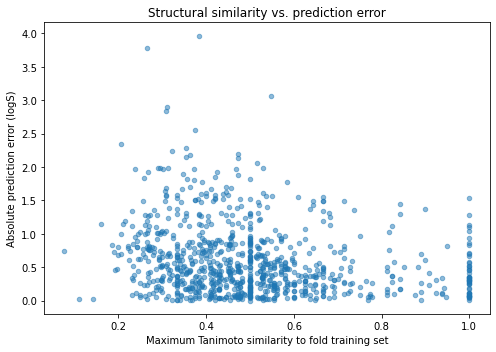

In [68]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.base import clone
import matplotlib.pyplot as plt

# 按基准数据的行顺序重新生成指纹
similarity_smiles = df_clean.loc[
    benchmark_X.index, "canonical_smiles"
]

similarity_mols = [
    Chem.MolFromSmiles(s)
    for s in similarity_smiles
]

assert all(mol is not None for mol in similarity_mols)

similarity_generator = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=512
    )
)

similarity_fps = [
    similarity_generator.GetFingerprint(mol)
    for mol in similarity_mols
]

# 同时核对此前指纹表是否与分子顺序一致
rebuilt_fp_array = np.array([
    similarity_generator.GetFingerprintAsNumPy(mol)
    for mol in similarity_mols
])

assert np.array_equal(
    rebuilt_fp_array,
    fp_train.to_numpy()
), "指纹表与重新生成的指纹不一致，请先检查参数和行顺序"

similarity_rows = []

for fold_number, (fit_pos, val_pos) in enumerate(
    benchmark_folds, start=1
):
    print(f"正在分析第 {fold_number} 折", flush=True)

    model = clone(benchmark_models["RandomForest"])

    model.fit(
        benchmark_X.iloc[fit_pos],
        benchmark_y.iloc[fit_pos]
    )

    predictions = model.predict(
        benchmark_X.iloc[val_pos]
    )

    fit_fps = [
        similarity_fps[pos] for pos in fit_pos
    ]

    for val_position, prediction in zip(
        val_pos, predictions
    ):
        similarities = np.asarray(
            DataStructs.BulkTanimotoSimilarity(
                similarity_fps[val_position],
                fit_fps
            )
        )

        closest_position = fit_pos[
            int(np.argmax(similarities))
        ]

        measured = float(
            benchmark_y.iloc[val_position]
        )

        similarity_rows.append({
            "row_index": benchmark_X.index[val_position],
            "fold": fold_number,
            "max_similarity": float(similarities.max()),
            "nearest_train_index":
                benchmark_X.index[closest_position],
            "measured_logS": measured,
            "predicted_logS": float(prediction),
            "absolute_error": abs(prediction - measured)
        })

similarity_results = (
    pd.DataFrame(similarity_rows)
    .set_index("row_index")
)

assert len(similarity_results) == len(benchmark_X)
assert similarity_results.index.is_unique

# 固定区间，查看各相似度范围的样本数和误差
similarity_results["similarity_bin"] = pd.cut(
    similarity_results["max_similarity"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    include_lowest=True
)

similarity_summary = (
    similarity_results
    .groupby("similarity_bin", observed=True)
    .agg(
        molecule_count=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        median_error=("absolute_error", "median")
    )
)

print("\n相似度分组结果：")
display(similarity_summary.round(3))

spearman_rho = similarity_results[
    ["max_similarity", "absolute_error"]
].corr(method="spearman").iloc[0, 1]

print(
    "\nSpearman 秩相关系数：",
    round(spearman_rho, 3)
)

plt.figure(figsize=(7, 5))
plt.scatter(
    similarity_results["max_similarity"],
    similarity_results["absolute_error"],
    alpha=0.5,
    s=20
)
plt.xlabel("Maximum Tanimoto similarity to fold training set")
plt.ylabel("Absolute prediction error (logS)")
plt.title("Structural similarity vs. prediction error")
plt.tight_layout()
plt.show()

In [69]:
# 找到最大指纹相似度等于 1 的验证分子
identical_fp_pairs = similarity_results.loc[
    np.isclose(
        similarity_results["max_similarity"],
        1.0,
        rtol=0,
        atol=1e-12
    )
].copy()

query_indices = identical_fp_pairs.index
neighbor_indices = identical_fp_pairs[
    "nearest_train_index"
].to_numpy()

# 查询分子的信息
identical_fp_pairs["query_name"] = df_clean.loc[
    query_indices, "Compound ID"
].to_numpy()

identical_fp_pairs["query_smiles"] = df_clean.loc[
    query_indices, "canonical_smiles"
].to_numpy()

identical_fp_pairs["query_scaffold"] = df_clean.loc[
    query_indices, "scaffold"
].to_numpy()

# 对应的最近训练分子信息
identical_fp_pairs["neighbor_name"] = df_clean.loc[
    neighbor_indices, "Compound ID"
].to_numpy()

identical_fp_pairs["neighbor_smiles"] = df_clean.loc[
    neighbor_indices, "canonical_smiles"
].to_numpy()

identical_fp_pairs["same_canonical_smiles"] = (
    identical_fp_pairs["query_smiles"]
    == identical_fp_pairs["neighbor_smiles"]
)

print("最大指纹相似度为 1 的验证分子数：",
      len(identical_fp_pairs))

print("其中规范 SMILES 完全相同的数量：",
      identical_fp_pairs["same_canonical_smiles"].sum())

print("其中查询分子为空骨架的数量：",
      (identical_fp_pairs["query_scaffold"] == "").sum())

display(
    identical_fp_pairs[
        [
            "query_name",
            "query_smiles",
            "neighbor_name",
            "neighbor_smiles",
            "same_canonical_smiles",
            "absolute_error"
        ]
    ].head(15)
)

最大指纹相似度为 1 的验证分子数： 49
其中规范 SMILES 完全相同的数量： 0
其中查询分子为空骨架的数量： 41


,query_name,query_smiles,neighbor_name,neighbor_smiles,same_canonical_smiles,absolute_error
row_index,,,,,,
25,1-Heptanol,CCCCCCCO,1-Hexanol,CCCCCCO,False,0.332405
197,1-Nonyne,C#CCCCCCCC,1-Octyne,C#CCCCCCC,False,0.267982
347,Ethyl decanoate,CCCCCCCCCC(=O)OCC,Ethyl nonanoate,CCCCCCCCC(=O)OCC,False,0.091108
384,1-Octene,C=CCCCCCC,1-Decene,C=CCCCCCCCC,False,0.118991
477,1-Bromohexane,CCCCCCBr,1-Bromoheptane,CCCCCCCBr,False,0.690069
564,Ethyl octanoate,CCCCCCCC(=O)OCC,Ethyl nonanoate,CCCCCCCCC(=O)OCC,False,0.293710
613,1-Nonanol,CCCCCCCCCO,1-Hexanol,CCCCCCO,False,0.345632
734,Nonane,CCCCCCCCC,Tetradecane,CCCCCCCCCCCCCC,False,0.490258
969,1-Pentadecanol,CCCCCCCCCCCCCCCO,1-Hexanol,CCCCCCO,False,0.581678


正在计算预测区间：第 1 折
正在计算预测区间：第 2 折
正在计算预测区间：第 3 折
正在计算预测区间：第 4 折
正在计算预测区间：第 5 折

各折区间表现：


,molecule_count,coverage,mean_width,crossing_count
fold,,,,
1,252,0.913,2.528,0
2,167,0.850,2.657,0
3,167,0.868,2.531,0
4,167,0.826,2.384,0
5,167,0.749,2.473,0



整体实际覆盖率： 84.8%
平均区间宽度： 2.516 logS
原始上下限交叉数量： 0


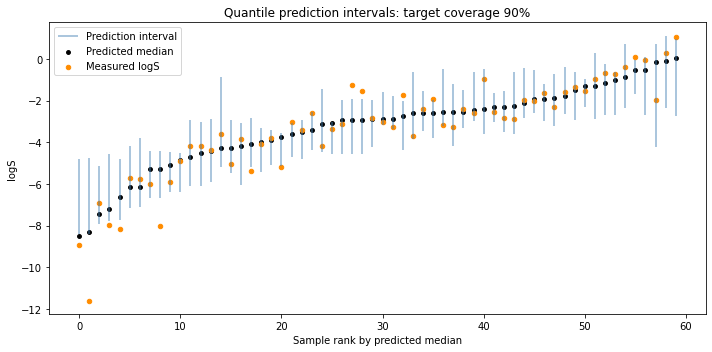

In [70]:
from sklearn.ensemble import GradientBoostingRegressor

interval_rows = []

for fold_number, (fit_pos, val_pos) in enumerate(
    benchmark_folds, start=1
):
    print(
        f"正在计算预测区间：第 {fold_number} 折",
        flush=True
    )

    X_fit = benchmark_X.iloc[fit_pos]
    y_fit = benchmark_y.iloc[fit_pos]

    X_val = benchmark_X.iloc[val_pos]
    y_val = benchmark_y.iloc[val_pos].to_numpy()

    quantile_predictions = {}

    # 下限、中位数、上限
    for quantile in [0.05, 0.50, 0.95]:
        model = GradientBoostingRegressor(
            loss="quantile",
            alpha=quantile,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=2,
            random_state=42
        )

        model.fit(X_fit, y_fit)

        quantile_predictions[quantile] = (
            model.predict(X_val)
        )

    raw_lower = quantile_predictions[0.05]
    median_pred = quantile_predictions[0.50]
    raw_upper = quantile_predictions[0.95]

    # 记录上下限交叉，并用较小值/较大值整理区间
    crossed = raw_lower > raw_upper
    lower = np.minimum(raw_lower, raw_upper)
    upper = np.maximum(raw_lower, raw_upper)

    for position, measured, median, lo, hi, crossing in zip(
        val_pos,
        y_val,
        median_pred,
        lower,
        upper,
        crossed
    ):
        interval_rows.append({
            "row_index": benchmark_X.index[position],
            "fold": fold_number,
            "measured_logS": measured,
            "median_prediction": median,
            "lower": lo,
            "upper": hi,
            "width": hi - lo,
            "covered": lo <= measured <= hi,
            "bounds_crossed": bool(crossing)
        })

interval_results = (
    pd.DataFrame(interval_rows)
    .set_index("row_index")
)

assert len(interval_results) == len(benchmark_X)
assert interval_results.index.is_unique

interval_summary = (
    interval_results
    .groupby("fold")
    .agg(
        molecule_count=("covered", "size"),
        coverage=("covered", "mean"),
        mean_width=("width", "mean"),
        crossing_count=("bounds_crossed", "sum")
    )
)

print("\n各折区间表现：")
display(interval_summary.round(3))

print(
    "\n整体实际覆盖率：",
    f"{interval_results['covered'].mean():.1%}"
)
print(
    "平均区间宽度：",
    round(interval_results["width"].mean(), 3),
    "logS"
)
print(
    "原始上下限交叉数量：",
    interval_results["bounds_crossed"].sum()
)

# 固定随机抽取 60 条，仅用于展示
plot_intervals = (
    interval_results
    .sample(n=min(60, len(interval_results)), random_state=42)
    .sort_values("median_prediction")
)

positions = np.arange(len(plot_intervals))

plt.figure(figsize=(10, 5))

plt.vlines(
    positions,
    plot_intervals["lower"],
    plot_intervals["upper"],
    color="steelblue",
    alpha=0.6,
    label="Prediction interval"
)

plt.scatter(
    positions,
    plot_intervals["median_prediction"],
    s=15,
    color="black",
    label="Predicted median"
)

plt.scatter(
    positions,
    plot_intervals["measured_logS"],
    s=20,
    color="darkorange",
    label="Measured logS"
)

plt.xlabel("Sample rank by predicted median")
plt.ylabel("logS")
plt.title("Quantile prediction intervals: target coverage 90%")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
from sklearn.model_selection import GroupShuffleSplit

miscoverage = 0.10  # 目标覆盖率为 90%
calibration_rows = []
calibration_split_rows = []

for fold_number, (outer_fit_pos, val_pos) in enumerate(
    benchmark_folds, start=1
):
    print(
        f"正在进行区间校准：第 {fold_number} 折",
        flush=True
    )

    outer_X = benchmark_X.iloc[outer_fit_pos]
    outer_y = benchmark_y.iloc[outer_fit_pos]
    outer_groups = benchmark_groups.iloc[outer_fit_pos]

    # 仅在外层训练数据内部划出校准集
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=42 + fold_number
    )

    fit_local, cal_local = next(
        splitter.split(
            outer_X,
            outer_y,
            groups=outer_groups
        )
    )

    fit_pos = outer_fit_pos[fit_local]
    cal_pos = outer_fit_pos[cal_local]

    # 三部分分组互不重叠
    fit_groups = set(benchmark_groups.iloc[fit_pos])
    cal_groups = set(benchmark_groups.iloc[cal_pos])
    val_groups = set(benchmark_groups.iloc[val_pos])

    assert fit_groups.isdisjoint(cal_groups)
    assert fit_groups.isdisjoint(val_groups)
    assert cal_groups.isdisjoint(val_groups)

    cal_predictions = {}
    val_predictions = {}

    for quantile in [0.05, 0.95]:
        model = GradientBoostingRegressor(
            loss="quantile",
            alpha=quantile,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=2,
            random_state=42
        )

        model.fit(
            benchmark_X.iloc[fit_pos],
            benchmark_y.iloc[fit_pos]
        )

        cal_predictions[quantile] = model.predict(
            benchmark_X.iloc[cal_pos]
        )
        val_predictions[quantile] = model.predict(
            benchmark_X.iloc[val_pos]
        )

    cal_lower = np.minimum(
        cal_predictions[0.05], cal_predictions[0.95]
    )
    cal_upper = np.maximum(
        cal_predictions[0.05], cal_predictions[0.95]
    )

    y_cal = benchmark_y.iloc[cal_pos].to_numpy()

    # 使用只扩展、不收缩区间的保守版本
    calibration_scores = np.maximum(
        np.maximum(cal_lower - y_cal, y_cal - cal_upper),
        0.0
    )

    # 有限样本修正：取第 ceil((n+1)*0.9) 个顺序统计量
    n_cal = len(calibration_scores)
    rank = int(np.ceil((n_cal + 1) * (1 - miscoverage)))

    correction = (
        np.sort(calibration_scores)[rank - 1]
        if rank <= n_cal
        else np.inf
    )

    raw_lower = np.minimum(
        val_predictions[0.05], val_predictions[0.95]
    )
    raw_upper = np.maximum(
        val_predictions[0.05], val_predictions[0.95]
    )

    calibrated_lower = raw_lower - correction
    calibrated_upper = raw_upper + correction

    y_val = benchmark_y.iloc[val_pos].to_numpy()

    calibration_split_rows.append({
        "fold": fold_number,
        "fit_count": len(fit_pos),
        "calibration_count": n_cal,
        "validation_count": len(val_pos),
        "correction": correction
    })

    for method, lower, upper in [
        ("Raw", raw_lower, raw_upper),
        ("Calibrated", calibrated_lower, calibrated_upper)
    ]:
        for position, measured, lo, hi in zip(
            val_pos, y_val, lower, upper
        ):
            calibration_rows.append({
                "row_index": benchmark_X.index[position],
                "fold": fold_number,
                "method": method,
                "covered": lo <= measured <= hi,
                "width": hi - lo
            })

calibration_results = pd.DataFrame(calibration_rows)

print("\n数据划分与校准扩展量：")
display(pd.DataFrame(calibration_split_rows).round(3))

print("\n各折校准前后表现：")
display(
    calibration_results
    .groupby(["fold", "method"])
    .agg(
        coverage=("covered", "mean"),
        mean_width=("width", "mean")
    )
    .round(3)
)

calibration_summary = (
    calibration_results
    .groupby("method")
    .agg(
        molecule_count=("covered", "size"),
        coverage=("covered", "mean"),
        mean_width=("width", "mean")
    )
)

print("\n整体比较：")
display(calibration_summary.round(3))

正在进行区间校准：第 1 折
正在进行区间校准：第 2 折
正在进行区间校准：第 3 折
正在进行区间校准：第 4 折
正在进行区间校准：第 5 折

数据划分与校准扩展量：


,fold,fit_count,calibration_count,validation_count,correction
0,1,524,144,252,0.426
1,2,602,151,167,0.639
2,3,637,116,167,0.286
3,4,590,163,167,0.621
4,5,344,409,167,0.180



各折校准前后表现：


coverage  mean_width
fold method                          
1    Calibrated     0.960       3.154
     Raw            0.845       2.301
2    Calibrated     0.928       3.870
     Raw            0.826       2.592
3    Calibrated     0.928       3.064
     Raw            0.874       2.492
4    Calibrated     0.958       3.642
     Raw            0.832       2.399
5    Calibrated     0.826       2.842
     Raw            0.754       2.482


整体比较：


,molecule_count,coverage,mean_width
method,,,
Calibrated,920,0.924,3.300
Raw,920,0.828,2.439
